# 01. 탐색적 데이터 분석 (EDA) 


In [1]:

import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:

# 데이터 로드 경로를 유연하게 처리
candidate_paths = [
    '../data/raw/netflix_customer_churn.csv',
    './data/raw/netflix_customer_churn.csv',
    './netflix_customer_churn.csv',
    '../netflix_customer_churn.csv'
]

data_path = None
for path in candidate_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "데이터 파일을 찾지 못했습니다. \n"
        + "\n".join(candidate_paths)
    )

df = pd.read_csv(data_path)
print(f'데이터 경로: {data_path}')
print(f'데이터 크기: {df.shape}')
df.head()


데이터 경로: ../data/raw/netflix_customer_churn.csv
데이터 크기: (5000, 14)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.7300,29,Africa,TV,8.9900,1,Gift Card,1,0.4900,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.7000,19,Europe,Mobile,13.9900,1,Gift Card,5,0.0300,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.3200,10,Asia,TV,13.9900,0,Crypto,2,1.4800,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.5100,12,Oceania,TV,17.9900,1,Crypto,2,0.3500,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.8900,13,Africa,Mobile,13.9900,1,Crypto,2,0.1300,Action


## 1. 데이터 기본 구조 확인

In [3]:

print('=== info ===')
display(df.info())

print('\n=== 기술통계 ===')
display(df.describe(include='all').T)

print('\n=== 결측치 현황 ===')
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0] if (missing > 0).any() else pd.Series({'결측치': 0}))

print('\n=== 중복 행 수 ===')
print(df.duplicated().sum())


=== info ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory

None


=== 기술통계 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,a9b75100-82a8-427a-a208-72f24052884a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"5,000.0000",NaN,NaN,NaN,43.8474,15.5011,18.0000,30.0000,44.0000,58.0000,70.0000
gender,5000,3,Female,1711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,5000,3,Premium,1693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
watch_hours,"5,000.0000",NaN,NaN,NaN,11.6494,12.0147,0.0100,3.3375,8.0000,16.0300,110.4000
last_login_days,"5,000.0000",NaN,NaN,NaN,30.0898,17.5361,0.0000,15.0000,30.0000,45.0000,60.0000
region,5000,6,South America,873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,5000,5,Tablet,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_fee,"5,000.0000",NaN,NaN,NaN,13.6834,3.6921,8.9900,8.9900,13.9900,17.9900,17.9900
churned,"5,000.0000",NaN,NaN,NaN,0.5030,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000



=== 결측치 현황 ===


결측치    0
dtype: int64


=== 중복 행 수 ===
0


In [4]:

# 컬럼 그룹 정의
target_col = 'churned'
base_numeric_cols = ['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'avg_watch_time_per_day']
base_cat_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

numeric_cols = [c for c in base_numeric_cols if c in df.columns]
cat_cols = [c for c in base_cat_cols if c in df.columns]

print('수치형 변수:', numeric_cols)
print('범주형 변수:', cat_cols)


수치형 변수: ['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'avg_watch_time_per_day']
범주형 변수: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']


## 2. 파생 변수 생성
원본 변수만 보는 것보다, **행동 강도 / 휴면 위험 / 프로필 활용도** 같은 관점의  파생변수 생성하였습니다.

In [5]:

eda = df.copy()

# 0 division 보호
profiles_safe = eda['number_of_profiles'].replace(0, np.nan) if 'number_of_profiles' in eda.columns else np.nan

if set(['watch_hours', 'number_of_profiles']).issubset(eda.columns):
    eda['watch_hours_per_profile'] = eda['watch_hours'] / profiles_safe

if set(['avg_watch_time_per_day', 'number_of_profiles']).issubset(eda.columns):
    eda['avg_watch_time_per_profile'] = eda['avg_watch_time_per_day'] / profiles_safe

if set(['last_login_days', 'watch_hours']).issubset(eda.columns):
    eda['inactivity_to_watch_ratio'] = eda['last_login_days'] / (eda['watch_hours'] + 1)

if set(['last_login_days', 'avg_watch_time_per_day']).issubset(eda.columns):
    eda['reengagement_need_score'] = eda['last_login_days'] / (eda['avg_watch_time_per_day'] + 0.1)

if set(['watch_hours', 'avg_watch_time_per_day']).issubset(eda.columns):
    eda['watch_days_est'] = eda['watch_hours'] / (eda['avg_watch_time_per_day'] + 0.1)

# 분위수 기반 행동 세그먼트
if 'avg_watch_time_per_day' in eda.columns:
    low_thr = eda['avg_watch_time_per_day'].quantile(0.25)
    high_thr = eda['avg_watch_time_per_day'].quantile(0.75)
    eda['watch_intensity_segment'] = pd.cut(
        eda['avg_watch_time_per_day'],
        bins=[-np.inf, low_thr, high_thr, np.inf],
        labels=['저시청', '중간시청', '고시청']
    )

if 'last_login_days' in eda.columns:
    login_q1 = eda['last_login_days'].quantile(0.25)
    login_q3 = eda['last_login_days'].quantile(0.75)
    eda['recency_segment'] = pd.cut(
        eda['last_login_days'],
        bins=[-np.inf, login_q1, login_q3, np.inf],
        labels=['최근접속', '보통', '장기미접속']
    )

if set(['last_login_days', 'avg_watch_time_per_day']).issubset(eda.columns):
    eda['risk_segment'] = np.select(
        [
            (eda['last_login_days'] >= eda['last_login_days'].median()) & (eda['avg_watch_time_per_day'] <= eda['avg_watch_time_per_day'].median()),
            (eda['last_login_days'] >= eda['last_login_days'].median()) & (eda['avg_watch_time_per_day'] > eda['avg_watch_time_per_day'].median()),
            (eda['last_login_days'] < eda['last_login_days'].median()) & (eda['avg_watch_time_per_day'] <= eda['avg_watch_time_per_day'].median())
        ],
        ['고위험(미접속+저시청)', '관찰필요(미접속+고시청)', '관찰필요(최근접속+저시청)'],
        default='안정(최근접속+고시청)'
    )

if set(['subscription_type', 'payment_method']).issubset(eda.columns):
    eda['plan_payment_combo'] = eda['subscription_type'].astype(str) + ' | ' + eda['payment_method'].astype(str)

if set(['subscription_type', 'device']).issubset(eda.columns):
    eda['plan_device_combo'] = eda['subscription_type'].astype(str) + ' | ' + eda['device'].astype(str)

derived_cols = [c for c in eda.columns if c not in df.columns]
print('추가된 파생 변수:')
for c in derived_cols:
    print('-', c)

eda.head()


추가된 파생 변수:
- watch_hours_per_profile
- avg_watch_time_per_profile
- inactivity_to_watch_ratio
- reengagement_need_score
- watch_days_est
- watch_intensity_segment
- recency_segment
- risk_segment
- plan_payment_combo
- plan_device_combo


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,watch_hours_per_profile,avg_watch_time_per_profile,inactivity_to_watch_ratio,reengagement_need_score,watch_days_est,watch_intensity_segment,recency_segment,risk_segment,plan_payment_combo,plan_device_combo
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.7300,29,Africa,TV,8.9900,1,Gift Card,1,0.4900,Action,14.7300,0.4900,1.8436,49.1525,24.9661,중간시청,보통,안정(최근접속+고시청),Basic | Gift Card,Basic | TV
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.7000,19,Europe,Mobile,13.9900,1,Gift Card,5,0.0300,Sci-Fi,0.1400,0.0060,11.1765,146.1538,5.3846,저시청,보통,관찰필요(최근접속+저시청),Standard | Gift Card,Standard | Mobile
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.3200,10,Asia,TV,13.9900,0,Crypto,2,1.4800,Drama,8.1600,0.7400,0.5774,6.3291,10.3291,고시청,최근접속,안정(최근접속+고시청),Standard | Crypto,Standard | TV
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.5100,12,Oceania,TV,17.9900,1,Crypto,2,0.3500,Horror,2.2550,0.1750,2.1779,26.6667,10.0222,중간시청,최근접속,안정(최근접속+고시청),Premium | Crypto,Premium | TV
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.8900,13,Africa,Mobile,13.9900,1,Crypto,2,0.1300,Action,0.9450,0.0650,4.4983,56.5217,8.2174,중간시청,최근접속,관찰필요(최근접속+저시청),Standard | Crypto,Standard | Mobile


## 3. 타겟 변수 분포 확인

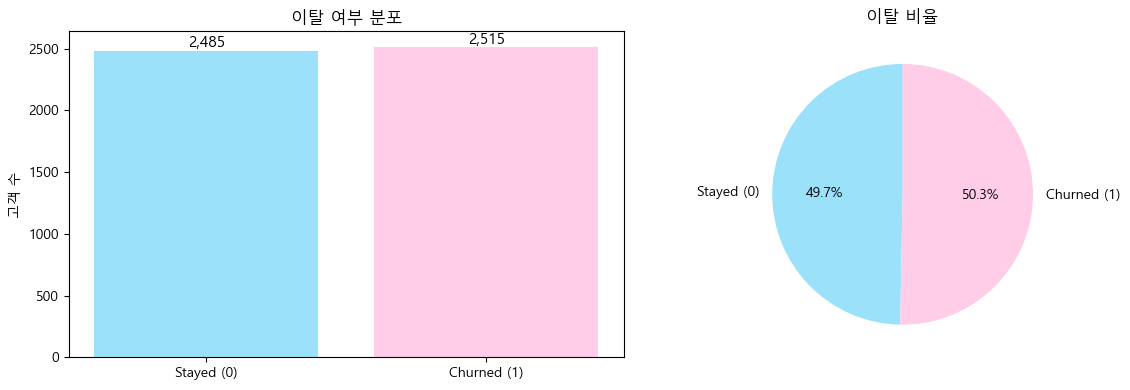

전체 이탈률: 50.30%


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = eda[target_col].value_counts().sort_index()
labels = ['Stayed (0)', 'Churned (1)']
colors = ["#9be1fa", "#ffcde7"]

axes[0].bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(10, counts.max()*0.01), f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('이탈 여부 분포')
axes[0].set_ylabel('고객 수')

axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title('이탈 비율')

plt.tight_layout()
plt.show()

overall_churn_rate = eda[target_col].mean()
print(f'전체 이탈률: {overall_churn_rate:.2%}')


## 4. 수치형 변수와 이탈의 관계
 **상관계수 / point-biserial correlation / 그룹 평균 차이 / 효과크기**까지 확인합니다.


In [7]:

def cohen_d(x0, x1):
    x0 = pd.Series(x0).dropna()
    x1 = pd.Series(x1).dropna()
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    n0, n1 = len(x0), len(x1)
    s0, s1 = x0.std(ddof=1), x1.std(ddof=1)
    pooled = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
    if pooled == 0:
        return 0
    return (x1.mean() - x0.mean()) / pooled

numeric_analysis_rows = []
numeric_analysis_cols = [c for c in eda.select_dtypes(include=np.number).columns if c != target_col]

for col in numeric_analysis_cols:
    try:
        corr, pval = pointbiserialr(eda[target_col], eda[col].fillna(eda[col].median()))
    except Exception:
        corr, pval = np.nan, np.nan

    stay = eda.loc[eda[target_col] == 0, col]
    churn = eda.loc[eda[target_col] == 1, col]
    numeric_analysis_rows.append({
        'variable': col,
        'mean_stayed': stay.mean(),
        'mean_churned': churn.mean(),
        'median_stayed': stay.median(),
        'median_churned': churn.median(),
        'diff_churn_minus_stay': churn.mean() - stay.mean(),
        'pointbiserial_corr': corr,
        'p_value': pval,
        'cohen_d': cohen_d(stay, churn)
    })

numeric_summary = pd.DataFrame(numeric_analysis_rows).sort_values(
    by='abs_corr', ascending=False
) if False else pd.DataFrame(numeric_analysis_rows)

numeric_summary['abs_corr'] = numeric_summary['pointbiserial_corr'].abs()
numeric_summary = numeric_summary.sort_values(by=['abs_corr', 'cohen_d'], ascending=[False, False])

display(numeric_summary.round(4))


,variable,mean_stayed,mean_churned,median_stayed,median_churned,diff_churn_minus_stay,pointbiserial_corr,p_value,cohen_d,abs_corr
9,reengagement_need_score,40.9751,190.7974,25.0000,163.6364,149.8223,0.6271,0.0000,1.6100,0.6271
8,inactivity_to_watch_ratio,1.7235,9.2177,1.2148,6.2147,7.4942,0.5168,0.0000,1.2070,0.5168
1,watch_hours,17.4496,5.9185,13.8600,4.0600,-11.5311,-0.4799,0.0000,-1.0939,0.4799
2,last_login_days,21.7710,38.3093,19.0000,41.0000,16.5383,0.4716,0.0000,1.0694,0.4716
6,watch_hours_per_profile,7.4215,3.0412,4.7600,1.5867,-4.3803,-0.3171,0.0000,-0.6685,0.3171
5,avg_watch_time_per_day,1.5941,0.1640,0.7200,0.1200,-1.4301,-0.2730,0.0000,-0.5674,0.2730
7,avg_watch_time_per_profile,0.7162,0.0877,0.2520,0.0480,-0.6285,-0.2563,0.0000,-0.5303,0.2563
4,number_of_profiles,3.2503,2.8012,3.0000,3.0000,-0.4491,-0.1586,0.0000,-0.3212,0.1586
3,monthly_fee,14.2484,13.1252,13.9900,13.9900,-1.1232,-0.1521,0.0000,-0.3078,0.1521
10,watch_days_est,18.5152,19.7375,16.2466,19.1176,1.2224,0.0500,0.0004,0.1001,0.0500


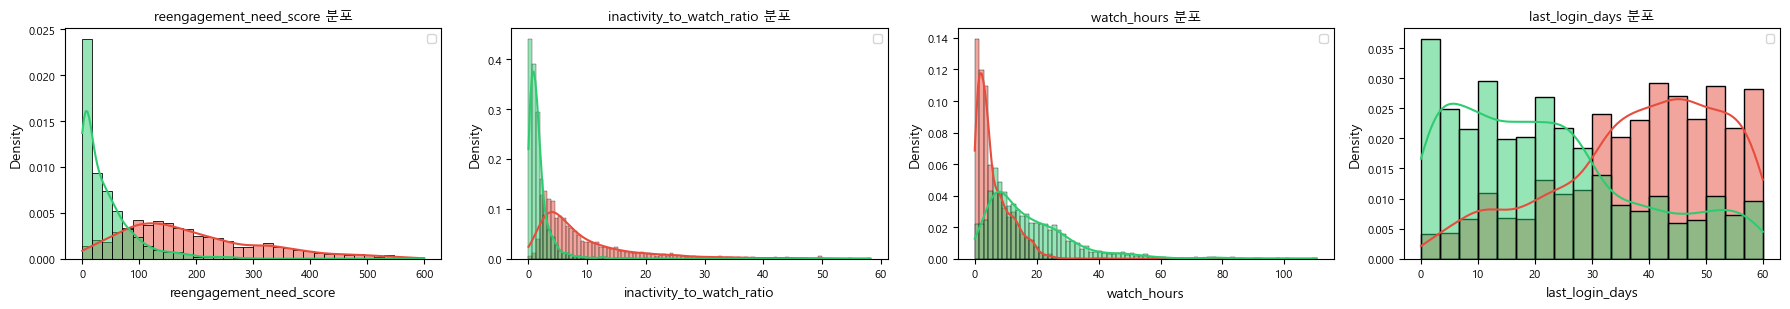

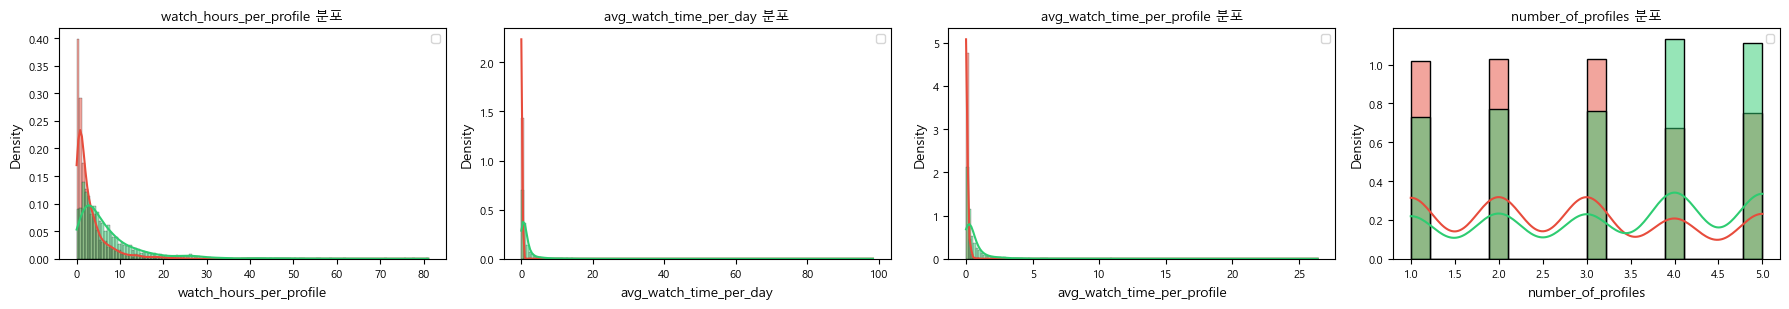

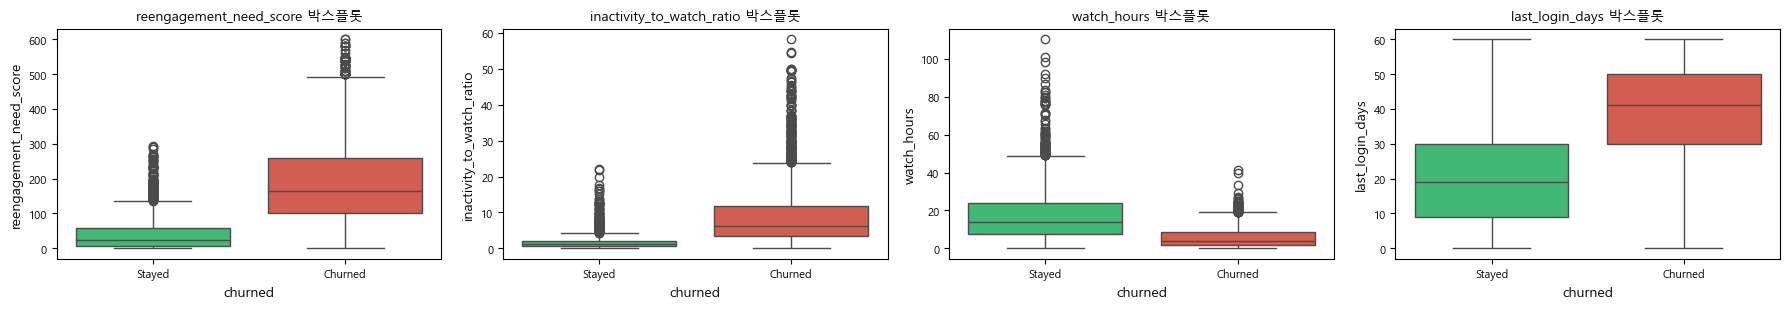

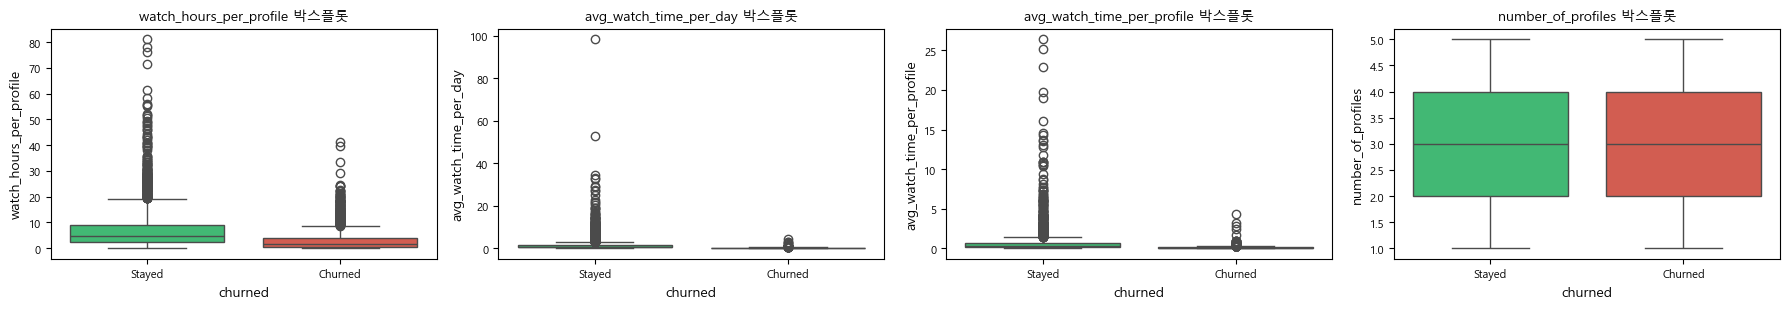

In [ ]:
# 주요 수치형 변수 분포 
top_numeric = numeric_summary['variable'].head(8).tolist()

for start in range(0, len(top_numeric), 4):
    subset = top_numeric[start:start+4]
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
    axes = np.atleast_1d(axes)

    for j, col in enumerate(subset):
        sns.histplot(
            data=eda, x=col, hue=target_col, kde=True, stat='density',
            common_norm=False, ax=axes[j], palette=['#2ecc71', '#e74c3c']
        )
        axes[j].set_title(f'{col} 분포', fontsize=10)
        axes[j].tick_params(axis='both', labelsize=8)
        if axes[j].get_legend() is not None:
            axes[j].legend(fontsize=8, title='')

    for k in range(len(subset), 4):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()

# 주요 수치형 변수 박스플롯
for start in range(0, len(top_numeric), 4):
    subset = top_numeric[start:start+4]
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
    axes = np.atleast_1d(axes)

    for j, col in enumerate(subset):
        sns.boxplot(data=eda, x=target_col, y=col, ax=axes[j], palette=['#2ecc71', '#e74c3c'])
        axes[j].set_xticklabels(['Stayed', 'Churned'])
        axes[j].set_title(f'{col} 박스플롯', fontsize=10)
        axes[j].tick_params(axis='both', labelsize=8)

    for k in range(len(subset), 4):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()


## 5. 범주형 변수와 이탈의 관계
범주형 변수는 단순 이탈률 비교뿐 아니라,  
- 카테고리별 이탈률
- 전체 평균 대비 Lift
- 카이제곱 검정
- Cramér's V 로 함께 분석하였습니다.


In [9]:

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    if n == 0:
        return np.nan
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))

cat_result_frames = []

for col in [c for c in eda.columns if eda[c].dtype == 'object' or str(eda[c].dtype).startswith('category')]:
    if col == target_col:
        continue

    tmp = eda.groupby(col)[target_col].agg(['mean', 'count', 'sum']).reset_index()
    tmp.columns = [col, 'churn_rate', 'count', 'churn_count']
    tmp['lift_vs_overall'] = tmp['churn_rate'] / overall_churn_rate

    ctab = pd.crosstab(eda[col], eda[target_col])
    if ctab.shape[0] >= 2 and ctab.shape[1] >= 2:
        chi2, p, _, _ = chi2_contingency(ctab)
        cv = cramers_v(ctab)
    else:
        p, cv = np.nan, np.nan

    tmp['variable'] = col
    tmp['chi2_p_value'] = p
    tmp['cramers_v'] = cv
    cat_result_frames.append(tmp)

cat_summary = pd.concat(cat_result_frames, ignore_index=True)
display(cat_summary.sort_values(['cramers_v', 'lift_vs_overall'], ascending=[False, False]).head(30).round(4))


,watch_intensity_segment,churn_rate,count,churn_count,lift_vs_overall,variable,chi2_p_value,cramers_v,recency_segment
0,저시청,0.9370,1269,1189,1.8627,watch_intensity_segment,0.0000,0.6592,NaN
1,중간시청,0.5281,2488,1314,1.0500,watch_intensity_segment,0.0000,0.6592,NaN
2,고시청,0.0097,1243,12,0.0192,watch_intensity_segment,0.0000,0.6592,NaN
5,NaN,0.7553,1230,929,1.5016,recency_segment,0.0000,0.3967,장기미접속
4,NaN,0.5326,2499,1331,1.0589,recency_segment,0.0000,0.3967,보통
3,NaN,0.2006,1271,255,0.3989,recency_segment,0.0000,0.3967,최근접속


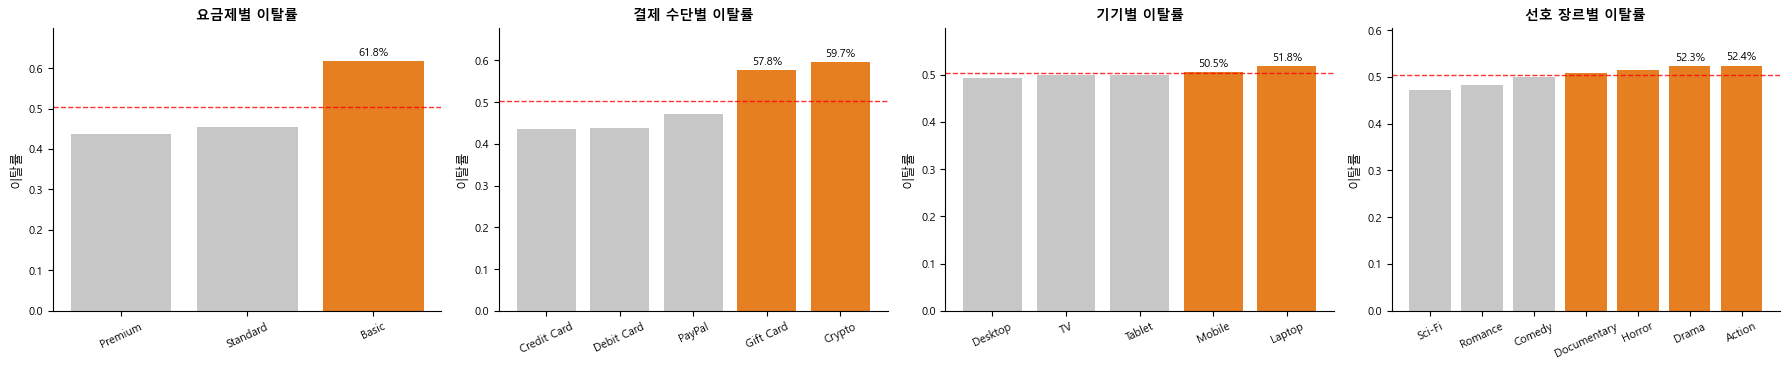

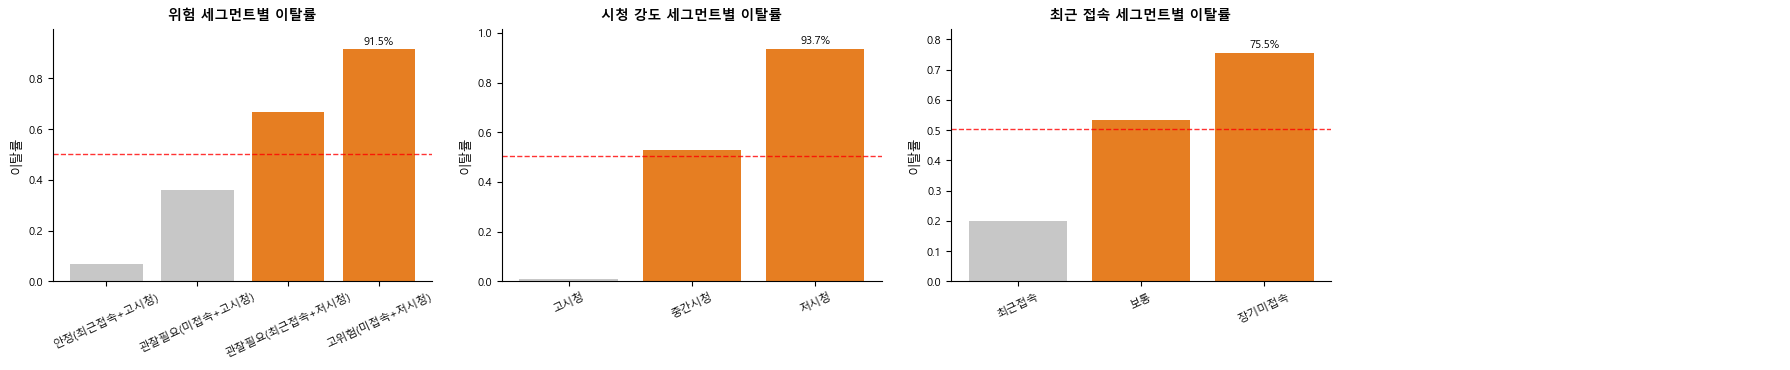

In [10]:
# 핵심 범주형 변수 시각화
import numpy as np
import matplotlib.pyplot as plt

plot_cols = []
for c in ['subscription_type', 'payment_method', 'device', 'favorite_genre',
          'risk_segment', 'watch_intensity_segment', 'recency_segment']:
    if c in eda.columns:
        plot_cols.append(c)

title_map = {
    'subscription_type': '요금제별 이탈률',
    'payment_method': '결제 수단별 이탈률',
    'device': '기기별 이탈률',
    'favorite_genre': '선호 장르별 이탈률',
    'risk_segment': '위험 세그먼트별 이탈률',
    'watch_intensity_segment': '시청 강도 세그먼트별 이탈률',
    'recency_segment': '최근 접속 세그먼트별 이탈률'
}

for start in range(0, len(plot_cols), 4):
    subset = plot_cols[start:start+4]
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
    axes = np.atleast_1d(axes)

    for i, col in enumerate(subset):
        tmp = eda.groupby(col)[target_col].mean().sort_values()

        # 평균 이상만 강조
        colors = ['#E67E22' if v >= overall_churn_rate else '#C7C7C7' for v in tmp.values]

        bars = axes[i].bar(
            tmp.index.astype(str),
            tmp.values,
            color=colors,
            edgecolor='none'
        )

        # 평균선
        axes[i].axhline(
            overall_churn_rate,
            color='red',
            linestyle='--',
            linewidth=1,
            alpha=0.8
        )

        # 중요한 값만 라벨 표시
        label_threshold = max(overall_churn_rate, tmp.quantile(0.75))
        for bar, v in zip(bars, tmp.values):
            if v >= label_threshold:
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    v + 0.005,
                    f'{v:.1%}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

        axes[i].set_title(title_map.get(col, f'{col}별 이탈률'), fontsize=10, weight='bold')
        axes[i].set_ylabel('이탈률', fontsize=9)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=25, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)

        # y축 범위 여유
        axes[i].set_ylim(0, max(tmp.max() + 0.08, overall_churn_rate + 0.08))

        # 테두리 단순화
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    for k in range(len(subset), 4):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()

## 6. 구간화/세그먼트 분석
“어떤 고객군이 특히 위험한가”
따라서 구간화 변수와 교차 세그먼트를 함께 봅니다.


In [11]:

# 구간화 변수
if 'last_login_days' in eda.columns:
    eda['login_group'] = pd.cut(
        eda['last_login_days'],
        bins=[-np.inf, 7, 14, 30, 45, np.inf],
        labels=['~7일', '8~14일', '15~30일', '31~45일', '46일+']
    )

if 'avg_watch_time_per_day' in eda.columns:
    eda['watch_group'] = pd.cut(
        eda['avg_watch_time_per_day'],
        bins=[-np.inf, 0.5, 1, 2, 5, np.inf],
        labels=['~30분', '30분~1시간', '1~2시간', '2~5시간', '5시간+']
    )

if 'age' in eda.columns:
    eda['age_group'] = pd.cut(
        eda['age'],
        bins=[17, 25, 35, 45, 55, 70, np.inf],
        labels=['18~25', '26~35', '36~45', '46~55', '56~70', '70+']
    )

segment_cols = [c for c in ['login_group', 'watch_group', 'age_group', 'risk_segment'] if c in eda.columns]

for col in segment_cols:
    seg = eda.groupby(col, observed=True)[target_col].agg(['mean', 'count']).reset_index()
    seg.columns = [col, 'churn_rate', 'count']
    display(seg.sort_values('churn_rate', ascending=False).round(4))


,login_group,churn_rate,count
4,46일+,0.7553,1230
3,31~45일,0.7466,1239
2,15~30일,0.3200,1322
1,8~14일,0.2701,559
0,~7일,0.1338,650


,watch_group,churn_rate,count
0,~30분,0.7520,3310
1,30분~1시간,0.0238,797
3,2~5시간,0.0139,288
2,1~2시간,0.0066,456
4,5시간+,0.0000,149


,age_group,churn_rate,count
3,46~55,0.5452,919
0,18~25,0.5069,801
1,26~35,0.5037,949
4,56~70,0.4873,1451
2,36~45,0.4807,880


,risk_segment,churn_rate,count
0,고위험(미접속+저시청),0.9151,1744
2,관찰필요(최근접속+저시청),0.6671,766
1,관찰필요(미접속+고시청),0.3588,811
3,안정(최근접속+고시청),0.0697,1679


In [12]:

# 교차 세그먼트 분석
cross_results = []

cross_candidates = [
    ('subscription_type', 'device'),
    ('subscription_type', 'payment_method'),
    ('subscription_type', 'favorite_genre'),
    ('risk_segment', 'subscription_type'),
    ('watch_intensity_segment', 'recency_segment')
]

for c1, c2 in cross_candidates:
    if c1 in eda.columns and c2 in eda.columns:
        tmp = eda.groupby([c1, c2])[target_col].agg(['mean', 'count']).reset_index()
        tmp.columns = [c1, c2, 'churn_rate', 'count']
        tmp = tmp[tmp['count'] >= max(5, int(len(eda) * 0.01))]  # 너무 희소한 조합 제거
        tmp['segment'] = tmp[c1].astype(str) + ' | ' + tmp[c2].astype(str)
        cross_results.append(tmp.sort_values('churn_rate', ascending=False).head(10))

if cross_results:
    cross_summary = pd.concat(cross_results, ignore_index=True)
    display(cross_summary[['segment', 'churn_rate', 'count']].sort_values('churn_rate', ascending=False).head(20).round(4))
else:
    cross_summary = pd.DataFrame(columns=['segment', 'churn_rate', 'count'])
    print('사용 가능한 교차 세그먼트가 없습니다.')


,segment,churn_rate,count
30,고위험(미접속+저시청) | Basic,0.9935,611
40,저시청 | 장기미접속,0.9776,491
41,저시청 | 보통,0.9299,685
31,관찰필요(최근접속+저시청) | Basic,0.8922,232
32,고위험(미접속+저시청) | Standard,0.8807,570
33,고위험(미접속+저시청) | Premium,0.8650,563
42,저시청 | 최근접속,0.7742,93
0,Basic | Laptop,0.6575,327
43,중간시청 | 장기미접속,0.6507,690
20,Basic | Drama,0.6468,235


## 7. 상관관계 히트맵

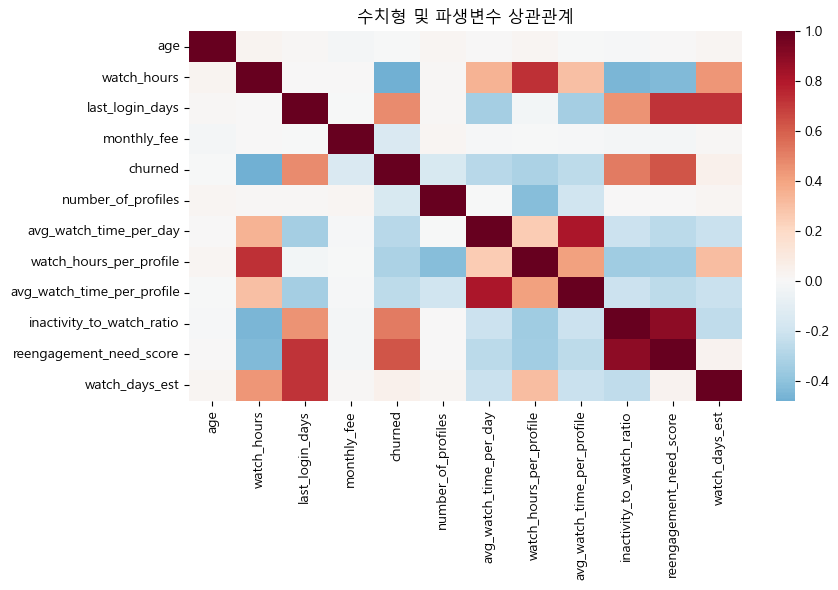

=== churned와의 상관관계 순위 ===


,corr_with_churn
reengagement_need_score,0.6271
inactivity_to_watch_ratio,0.5168
watch_hours,-0.4799
last_login_days,0.4716
watch_hours_per_profile,-0.3171
avg_watch_time_per_day,-0.2730
avg_watch_time_per_profile,-0.2563
number_of_profiles,-0.1586
monthly_fee,-0.1521
watch_days_est,0.0500


In [13]:
corr_cols = [c for c in eda.select_dtypes(include=np.number).columns if eda[c].nunique() > 1]
corr = eda[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, square=False)
plt.title('수치형 및 파생변수 상관관계')
plt.tight_layout()
plt.show()

target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
print('=== churned와의 상관관계 순위 ===')
display(target_corr.to_frame('corr_with_churn').round(4))
